In [4]:
    import pandas as pd

df_finance = pd.read_csv("../data/processed/preprocessed_finance_news.csv")

print(df_finance.shape)
df_finance.head()

(48742, 10)


,category,headline,authors,link,short_description,date,year,text,sector,clean_text
0,IMPACT,Top Charity Stunts Of 2012,Zoe Mintz,https://www.huffingtonpost.com/entry/best-char...,The charity sector saw a number of unexpected ...,2012-12-30,data_2012,Top Charity Stunts Of 2012 The charity sector ...,Automobile,top charity stunt charity sector see number un...
1,IMPACT,New Year's Resolutions: Don't Forget the Missi...,"Dave Santulli, Contributor\nFounder and Presid...",https://www.huffingtonpost.com/entry/new-years...,"Year after year, the same resolutions lead the...",2012-12-30,data_2012,New Year's Resolutions: Don't Forget the Missi...,Others,new year resolution forget miss one year year ...
2,IMPACT,Basketball Diaries: Afghanistan,"Peretz Partensky, Contributor\nCo-founder Sour...",https://www.huffingtonpost.com/entry/basketbal...,Most of the Afghan basketball players stepped ...,2012-12-30,data_2012,Basketball Diaries: Afghanistan Most of the Af...,Others,basketball diary afghanistan afghan basketball...
3,BUSINESS,The Best CEOs Of 2012: 24/7 Wall St.,"24/7 Wall St., 24/7 Wall St.",https://www.huffingtonpost.com/entry/best-ceos...,"However, current success does not mean future ...",2012-12-30,data_2012,"The Best CEOs Of 2012: 24/7 Wall St. However, ...",IT,good ceo wall however current success mean fut...
4,BUSINESS,"The Biggest Billionaire Scandals Of 2012, Acco...","Forbes, Forbes",https://www.huffingtonpost.com/entry/billionai...,"Fitzgerald, consummate chronicler of the haves...",2012-12-30,data_2012,"The Biggest Billionaire Scandals Of 2012, Acco...",IT,big billionaire scandal accord forbe fitzgeral...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85
)

In [7]:
X = tfidf.fit_transform(df_finance["clean_text"])
y = df_finance["sector"]

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [8]:
print(df_finance["clean_text"].isnull().sum())

4


In [9]:
df_finance["clean_text"] = df_finance["clean_text"].fillna("")

In [10]:
print(df_finance["clean_text"].isnull().sum())
print(df_finance.shape)

0
(48742, 10)


In [11]:
X = tfidf.fit_transform(df_finance["clean_text"])
y = df_finance["sector"]

print(X.shape)
print(y.shape)

(48742, 5000)
(48742,)


In [12]:
import pandas as pd

df_finance = pd.read_csv("../data/processed/preprocessed_finance_news.csv")
df_finance = df_finance.dropna(subset=["clean_text"])
df_finance = df_finance[df_finance["clean_text"].str.strip() != ""]

print(df_finance.shape)

(48738, 10)


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85
)

X = tfidf.fit_transform(df_finance["clean_text"])
y = df_finance["sector"]

print(X.shape)

(48738, 5000)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(38990, 5000)
(9748, 5000)


In [15]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred = nb_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.7204554780467788
              precision    recall  f1-score   support

  Automobile       0.79      0.29      0.42      1494
     Banking       0.90      0.28      0.42       159
      Energy       0.79      0.05      0.09       236
          IT       0.69      0.68      0.69      3226
      Others       0.73      0.96      0.83      4539
      Pharma       0.00      0.00      0.00        94

    accuracy                           0.72      9748
   macro avg       0.65      0.37      0.41      9748
weighted avg       0.72      0.72      0.69      9748



c:\Users\Rajesh Patil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rajesh Patil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rajesh Patil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


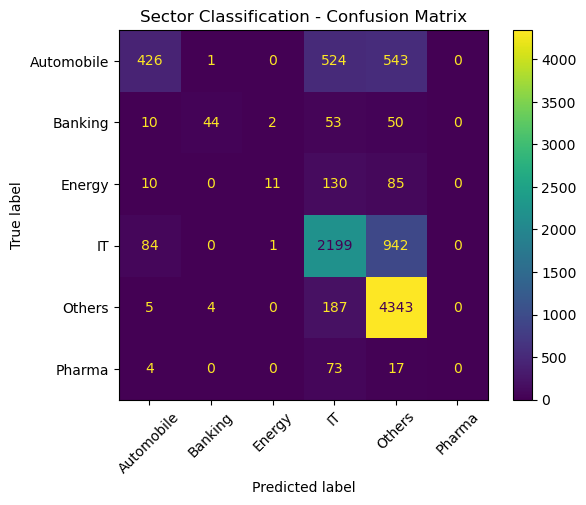

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.title("Sector Classification - Confusion Matrix")
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90
)

X = tfidf.fit_transform(df_model["clean_text"])
y = df_model["sector"]

print(X.shape)

NameError: name 'df_model' is not defined